In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import re
import numpy as np

splitbycap = '[A-Z][^A-Z]*'

matplotlib.rc('axes',edgecolor='k')
matplotlib.rc('xtick',labelsize=10)
matplotlib.rc('ytick',labelsize=10)
matplotlib.rc('axes',labelsize=16)
matplotlib.rc('axes',titlesize=16)
matplotlib.rc('axes',grid=False)

In [2]:
def get_data(path):
    with open(path, 'r') as f:
        data = json.load(f)
    return data

In [3]:
# alloy_pd = get_data('../DFTatMLIP results/alloy_space_overall_dict_EMPTY.json')

In [4]:
pure_phases_df = pd.read_parquet('pure_phases_df.parquet')
alloy_df = pd.read_parquet('alloy_df.parquet')
DOS_df = pd.read_parquet('dos_features.parquet')

In [5]:
DOS_columns_of_interest = ['formula', 'Efermi', 'vbm_up_energy', 'cbm_up_energy', 'vbm_down_energy', 'cbm_down_energy',
                           'is_alloy', 'x_frac', 'formula_0', 'formula_100']
# DOS_df[DOS_columns_of_interest]

In [6]:
data_columns_of_interest = ['formula', 'Eg', 'direct', 'dHf', 'dHd']

# alloy_df[data_columns_of_interest]
# pure_phases_df[data_columns_of_interest]

In [7]:
DOS_formulas = list(DOS_df['formula'])
data_formulas = list(alloy_df['formula'])+list(pure_phases_df['formula'])
count = 0
for formula in data_formulas:
    if formula not in DOS_formulas:
        # print(formula)
        count += 1
print(count, "formulas in data_df but not in DOS_df")


count = 0
for formula in DOS_formulas:
    if formula not in data_formulas:
        # print(formula)
        count += 1
print(count, "formulas in DOS_df but not in data_df")

169 formulas in data_df but not in DOS_df
57 formulas in DOS_df but not in data_df


In [8]:
def get_cbmvbm_Eg(band_edges: np.array) -> float:
    '''
    band_edges: np.array of shape (2,n) where the first row is the list of vbm energies and the second row is the list of cbm energies.
    in the case of non-spin-polarized calculations, there will be 1 vbm energy and 1 cbm energy (up and down spin energies are equal).
    in the case of spin-polarized calculations, there will be 2 vbm energies and 2 cbm energies (up and down spins).
    in the case of estimating the band gap of alloys from pure phases, there will be 4 vbm energies and 4 cbm energies (up and down spins of each pure phase).
    this function calculates the band gap by taking the minimum cbm - maximum vbm across all
    '''
    vbms = band_edges[0]
    cbms = band_edges[1]
    Eg_list = []
    for vbm in vbms:
        for cbm in cbms:
                Eg_cbm_vbm = cbm - vbm if cbm - vbm > 0 else 0
                Eg_list.append(Eg_cbm_vbm)
    return min(Eg_list)

In [9]:
def plot_parity(x_vals, y_vals, x_label, y_label, title=None, figsize=(6,6)):
    plt.figure(figsize=figsize)
    plt.scatter(x_vals, y_vals, color='blue', marker='o', edgecolors='k', alpha=0.7)
    plt.plot([-100, 100], [-100, 100], 'r--') # add y=x line for reference
    plt.plot([-100, 100], [-100.5, 99.5], 'g--') # add y=x line for reference
    plt.plot([-100, 100], [-99.5, 100.5], 'g--') # add y=x line for reference

    plt.xlim(min(x_vals+y_vals)-0.5, max(x_vals+y_vals)+0.5)
    plt.ylim(min(x_vals+y_vals)-0.5, max(x_vals+y_vals)+0.5)

    plt.xlabel(x_label)
    plt.ylabel(y_label)

    plt.title(title)

    plt.show()

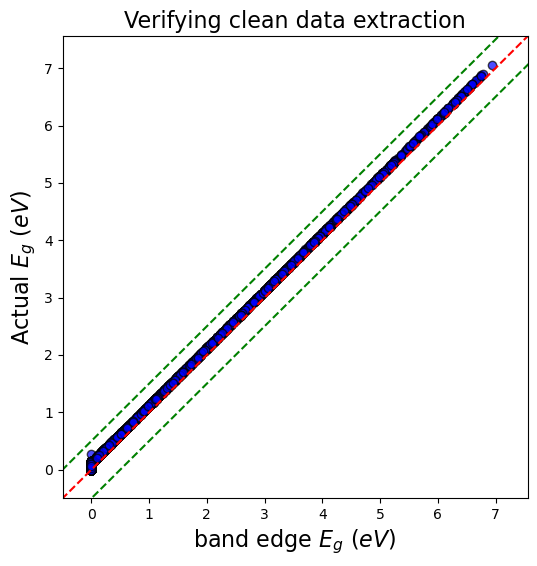

In [10]:
# Exploratory Data Analysis (EDA), Verification
# extract cbm-vbm between up and down spins (up-up, down-down, up-down, down-up) from DOS_dict, take minimum
DOS_formulas_list = list(DOS_df['formula'])
vbm_up_energy_list = list(DOS_df['vbm_up_energy'])
cbm_up_energy_list = list(DOS_df['cbm_up_energy'])
vbm_down_energy_list = list(DOS_df['vbm_down_energy'])
cbm_down_energy_list = list(DOS_df['cbm_down_energy'])

alloy_Eg_band_edges_dict = {}
for formula, vbm_up_energy, cbm_up_energy, vbm_down_energy, cbm_down_energy in zip(DOS_formulas_list, vbm_up_energy_list, cbm_up_energy_list, vbm_down_energy_list, cbm_down_energy_list):
    band_edges = np.array([[vbm_up_energy, vbm_down_energy], [cbm_up_energy, cbm_down_energy]])
    Eg = get_cbmvbm_Eg(band_edges)
    alloy_Eg_band_edges_dict[formula] = Eg

# extract Eg from data_dict
data_formulas = list(alloy_df['formula'])+list(pure_phases_df['formula'])
data_Eg_list = list(alloy_df['Eg'])+list(pure_phases_df['Eg'])
data_Eg_dict = {}
for formula, Eg in zip(data_formulas, data_Eg_list):
    data_Eg_dict[formula] = Eg

# compare the two, there should be close matching if extraction using Claude Code is done correctly
formula_list = list(set(alloy_Eg_band_edges_dict.keys()) & set(data_Eg_dict.keys())) # only formulas that are in both dicts, to compare the two Eg values
alloy_Eg_band_edges_list = []
data_Eg_list = []
# mismatch_dict = {} #commented out because data extraction is now clean, no mismatches to analyze
# match_dict = {}
metallic_edge_cases = {}
for formula in formula_list:
    alloy_Eg_band_edges_list.append(alloy_Eg_band_edges_dict[formula])
    data_Eg_list.append(data_Eg_dict[formula])
    # mismatch = alloy_Eg_band_edges_dict[formula]-data_Eg_dict[formula]
    # if abs(mismatch) > 0.5:
    #     mismatch_dict[formula] = mismatch
    # if abs(mismatch) <= 0.11:
    #     match_dict[formula] = mismatch
    if (data_Eg_dict[formula] == 0 and alloy_Eg_band_edges_dict[formula] > 0) or (data_Eg_dict[formula] > 0 and alloy_Eg_band_edges_dict[formula] == 0):
        metallic_edge_cases[formula] = (alloy_Eg_band_edges_dict[formula], data_Eg_dict[formula])

plot_parity(alloy_Eg_band_edges_list, data_Eg_list, 'band edge $E_g$ $(eV)$', 'Actual $E_g$ $(eV)$', title='Verifying clean data extraction')

Total: 6521 | Metallic (Eg=0): 2050 (31.4%) | Semiconducting: 4471 (68.6%)


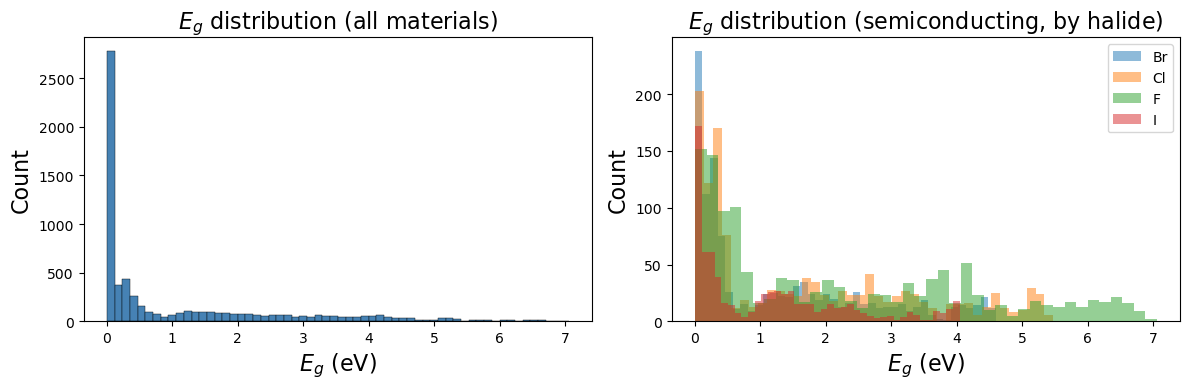

In [11]:
# Target variable distribution
all_Eg = pd.concat([alloy_df[['formula', 'Eg', 'X']],
                    pure_phases_df[['formula', 'Eg', 'X']]]).dropna(subset=['Eg'])

n_total    = len(all_Eg)
n_metallic = (all_Eg['Eg'] == 0).sum()
print(f"Total: {n_total} | Metallic (Eg=0): {n_metallic} ({100*n_metallic/n_total:.1f}%) | "
      f"Semiconducting: {n_total-n_metallic} ({100*(n_total-n_metallic)/n_total:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full distribution. Note spike at Eg=0, large fraction of perovskites are metallic
axes[0].hist(all_Eg['Eg'], bins=60, color='steelblue', edgecolor='k', linewidth=0.3)
axes[0].set_xlabel('$E_g$ (eV)')
axes[0].set_ylabel('Count')
axes[0].set_title('$E_g$ distribution (all materials)')

# Semiconducting only, by halide. Note still large fraction of low Eg perovskites.
# Eg max ranking F>Cl>Br>I, connects to decrease in electronegativity
for X, sub in all_Eg[all_Eg['Eg'] > -0].groupby('X'):
    axes[1].hist(sub['Eg'], bins=40, alpha=0.5, label=X)
axes[1].set_xlabel('$E_g$ (eV)')
axes[1].set_ylabel('Count')
axes[1].set_title('$E_g$ distribution (semiconducting, by halide)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
# Exploratory Data Analysis (EDA), Trend Observation
# extract cbm-vbm between up and down spins (up-up, down-down, up-down, down-up) of PURE PHASES from DOS_dict, take minimum
# extract Eg from data_dict
# compare the two, observe trend

In [13]:
#extract vbm and cbm energies for pure phases only, to compare with Eg from data_dict for pure phases only
DOS_formulas_list = list(DOS_df['formula'])
vbm_up_energy_list = list(DOS_df['vbm_up_energy'])
cbm_up_energy_list = list(DOS_df['cbm_up_energy'])
vbm_down_energy_list = list(DOS_df['vbm_down_energy'])
cbm_down_energy_list = list(DOS_df['cbm_down_energy'])
pure_phase_1_list = list(DOS_df['formula_0'])
pure_phase_2_list = list(DOS_df['formula_100'])
x_frac_list = list(DOS_df['x_frac'])
is_alloy_list = list(DOS_df['is_alloy'])

cbm_vbm_dict = {}
for formula, vbm_up_energy, cbm_up_energy, vbm_down_energy, cbm_down_energy, x_frac, formula_0, formula_100, is_alloy in zip(DOS_formulas_list, vbm_up_energy_list, cbm_up_energy_list, vbm_down_energy_list, cbm_down_energy_list, x_frac_list, pure_phase_1_list, pure_phase_2_list, is_alloy_list):
    band_edges = np.array([[vbm_up_energy, vbm_down_energy], [cbm_up_energy, cbm_down_energy]])
    Eg = get_cbmvbm_Eg(band_edges)
    cbm_vbm_dict[formula] = {'vbm_up': vbm_up_energy, 'cbm_up': cbm_up_energy,
                             'vbm_down': vbm_down_energy, 'cbm_down': cbm_down_energy,
                             'Eg_band_edges': Eg,
                             'x_frac': x_frac, 'formula_100': formula_100, 'formula_0': formula_0, 'is_alloy': is_alloy}

# DFT Eg extracted from alloy_df and pure_phases_df, done from data verification EDA
# data_Eg_dict

# extract cbm-vbm between up and down spins (up-up, down-down, up-down, down-up) of PURE PHASES from DOS_dict, take minimum
formula_list = list(set(cbm_vbm_dict.keys()) & set(data_Eg_dict.keys())) # only formulas that are in both dicts, to compare the two Eg values
alloy_Eg_from_pure_phases_dict = {}
for formula in formula_list:
    is_alloy = cbm_vbm_dict[formula]['is_alloy']
    if is_alloy == True:
        Eg_DFT = data_Eg_dict[formula]
        Eg_band_edges = cbm_vbm_dict[formula]['Eg_band_edges']
        x_frac = cbm_vbm_dict[formula]['x_frac']

        formula_0 = cbm_vbm_dict[formula]['formula_0']
        formula_100 = cbm_vbm_dict[formula]['formula_100']
        if formula_0 in formula_list and formula_100 in formula_list: # check if pure phases are in the list of formulas to analyze, if not, skip this alloy for now (can analyze separately later)
            Eg_DFT_0 = data_Eg_dict[formula_0]
            Eg_DFT_100 = data_Eg_dict[formula_100]
            vbm_up_0, cbm_up_0 = cbm_vbm_dict[formula_0]['vbm_up'], cbm_vbm_dict[formula_0]['cbm_up']
            vbm_down_0, cbm_down_0 = cbm_vbm_dict[formula_0]['vbm_down'], cbm_vbm_dict[formula_0]['cbm_down']
            vbm_up_100, cbm_up_100 = cbm_vbm_dict[formula_100]['vbm_up'], cbm_vbm_dict[formula_100]['cbm_up']
            vbm_down_100, cbm_down_100 = cbm_vbm_dict[formula_100]['vbm_down'], cbm_vbm_dict[formula_100]['cbm_down']
            
            Eg_pure_phases_DFT_frac_weighted = (1-x_frac)*Eg_DFT_0 + x_frac*Eg_DFT_100
            band_edges_pure_phases = np.array([[vbm_up_0, vbm_down_0, vbm_up_100, vbm_down_100], [cbm_up_0, cbm_down_0, cbm_up_100, cbm_down_100]])
            Eg_pure_phases_band_edges = get_cbmvbm_Eg(band_edges_pure_phases)
            band_edges_pure_phases_frac_weighted = np.array([[vbm_up_0*(1-x_frac)+vbm_up_100*x_frac, vbm_down_0*(1-x_frac)+vbm_down_100*x_frac],
                                                            [cbm_up_0*(1-x_frac)+cbm_up_100*x_frac, cbm_down_0*(1-x_frac)+cbm_down_100*x_frac]])
            Eg_pure_phases_band_edges_frac_weighted = get_cbmvbm_Eg(band_edges_pure_phases_frac_weighted)
            alloy_Eg_from_pure_phases_dict[formula] = {'Eg_DFT': Eg_DFT, 'Eg_band_edges': Eg_band_edges,
                                                       'Eg_pure_phases_DFT_frac_weighted': Eg_pure_phases_DFT_frac_weighted,
                                                       'Eg_pure_phases_band_edges': Eg_pure_phases_band_edges,
                                                       'Eg_pure_phases_band_edges_frac_weighted': Eg_pure_phases_band_edges_frac_weighted}
        # else:
        #     print(f"Skipping alloy {formula} because pure phases not in formula list")

In [14]:
# all plottable data extracted into lists for parity plots and trend observation
Eg_DFT_list = []
Eg_band_edges_list = []
Eg_pure_phases_DFT_frac_weighted_list = []
Eg_pure_phases_band_edges_list = []
Eg_pure_phases_band_edges_frac_weighted_list = []
# mismatch_dict = {} #commented out because data extraction is now clean, no mismatches to analyze
# match_dict = {}
# metallic_edge_cases = {}
for formula, values in alloy_Eg_from_pure_phases_dict.items():
    Eg_DFT_list.append(values['Eg_DFT'])
    Eg_band_edges_list.append(values['Eg_band_edges'])
    Eg_pure_phases_DFT_frac_weighted_list.append(values['Eg_pure_phases_DFT_frac_weighted'])
    Eg_pure_phases_band_edges_list.append(values['Eg_pure_phases_band_edges'])
    Eg_pure_phases_band_edges_frac_weighted_list.append(values['Eg_pure_phases_band_edges_frac_weighted'])
    # mismatch = alloy_Eg_band_edges_dict[formula]-data_Eg_dict[formula]
    # if abs(mismatch) > 0.5:
    #     mismatch_dict[formula] = mismatch
    # if abs(mismatch) <= 0.11:
    #     match_dict[formula] = mismatch
    # if (data_Eg_dict[formula] == 0 and alloy_Eg_band_edges_dict[formula] > 0) or (data_Eg_dict[formula] > 0 and alloy_Eg_band_edges_dict[formula] == 0):
    #     metallic_edge_cases[formula] = (alloy_Eg_band_edges_dict[formula], data_Eg_dict[formula])

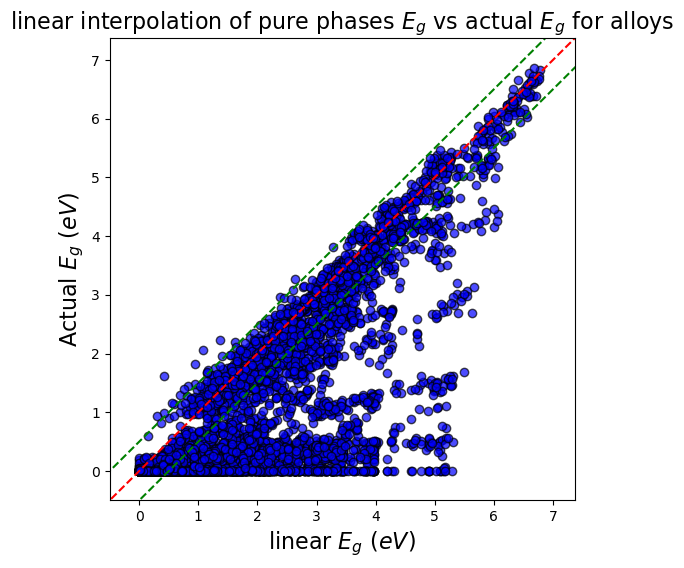

In [15]:
# Actual Eg vs linear interpolation of pure phases Eg
plot_parity(Eg_pure_phases_DFT_frac_weighted_list, Eg_DFT_list, 'linear $E_g$ $(eV)$', 'Actual $E_g$ $(eV)$', title='linear interpolation of pure phases $E_g$ vs actual $E_g$ for alloys')

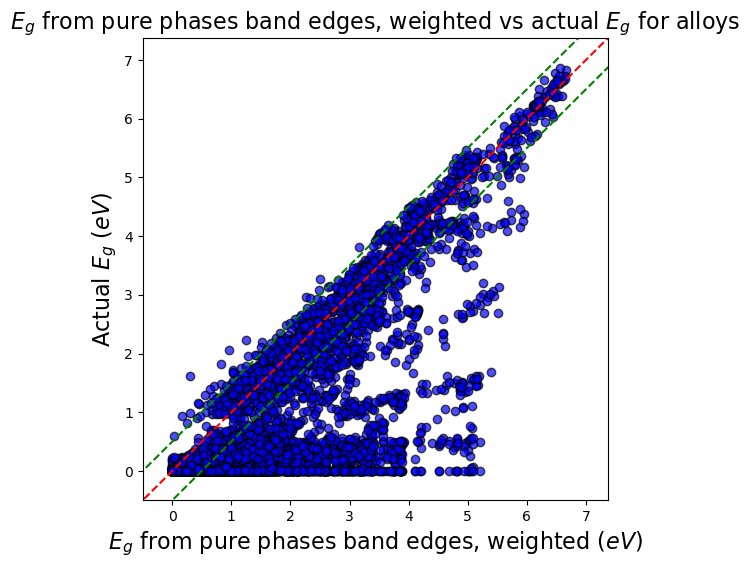

In [16]:
# # Actual Eg vs Eg from pure phases band edges
# plot_parity(Eg_pure_phases_band_edges_list, Eg_DFT_list, '$E_g$ from pure phases band edges $(eV)$', 'Actual $E_g$ $(eV)$', title='$E_g$ from pure phases band edges vs actual $E_g$ for alloys')

# Actual Eg vs Eg from pure phases band edges, weighted
plot_parity(Eg_pure_phases_band_edges_frac_weighted_list, Eg_DFT_list, '$E_g$ from pure phases band edges, weighted $(eV)$', 'Actual $E_g$ $(eV)$', title='$E_g$ from pure phases band edges, weighted vs actual $E_g$ for alloys')

In [17]:
# EDA, bowing parameter fitting
# use alloy_space_overall_dict_EMPTY.json to help group alloys by formula space for fitting.
    # Ignore alloys without Eg for all 5 x_frac values (0, 0.25, 0.5, 0.75, 1) for now, to have consistent data for fitting. Can analyze alloys without all 5 x_frac values separately later.
alloy_space_dict = get_data('alloy_space_overall_dict_EMPTY.json')
# Fit: Eg = (1-x)*Eg_0 + x*Eg_100 - b*x*(1-x), where b is the bowing parameter to fit.
    # b = ((1-x)*Eg_0 + x*Eg_100 - Eg_alloy)/(x*(1-x)).
    # Multilinear regression can be used to fit b across multiple alloys in the same formula space
    # Objective function: SSE = sum((Eg_alloy - ((1-x)*Eg_0 + x*Eg_100 - b*x*(1-x)))^2), minimize with respect to b?
# Eg_alloy vs Eg_bowing = (1-x)*Eg_0 + x*Eg_100 - b*x*(1-x)
    # parity plot, see if b improves over purely linear fit
    # if not, explain why and how it motivates ML models that can capture more complex relationships than just a single bowing parameter.
# if b is well behaved, histogram of b values by halide, and by B-site element group AEM/TM/PTM

In [18]:
AEM = {'Mg', 'Ca', 'Sr', 'Ba'}
TM  = {'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn',
       'Y', 'Zr', 'Nb', 'Mo', 'Ru', 'Rh', 'Pd', 'Ag', 'Cd',
       'Hf', 'Ta', 'W', 'Re', 'Os', 'Ir', 'Pt', 'Au', 'Hg'}
PTM = {'Al', 'Ga', 'In', 'Tl', 'Sn', 'Pb', 'Bi', 'Sb', 'Ge'}

def classify_B(el):
    if el in AEM: return 'AEM'
    if el in TM:  return 'TM'
    if el in PTM: return 'PTM'
    return 'Other'

pure_Eg = dict(zip(pure_phases_df['formula'], pure_phases_df['Eg']))


In [19]:
bowing_rows = []
parity_rows = []

for (f0, f100, B1, B2, X), grp in alloy_df.groupby(['formula_0', 'formula_100', 'B1', 'B2', 'X']):
    Eg0   = pure_Eg.get(f0)
    Eg100 = pure_Eg.get(f100)
    grp   = grp.dropna(subset=['Eg'])

    if Eg0 is None or Eg100 is None or pd.isna(Eg0) or pd.isna(Eg100) or len(grp) < 3:
        continue

    x_arr     = grp['x'].values / 100.0          # 0.25, 0.5, 0.75
    Eg_alloy  = grp['Eg'].values
    Eg_linear = (1 - x_arr) * Eg0 + x_arr * Eg100
    weight    = x_arr * (1 - x_arr)              # x*(1-x)
    residual  = Eg_linear - Eg_alloy

    b         = np.dot(weight, residual) / np.dot(weight, weight)  # closed-form LSQ
    Eg_bowing = Eg_linear - b * weight

    B_pair = '-'.join(sorted([classify_B(B1), classify_B(B2)]))
    bowing_rows.append({'formula_0': f0, 'formula_100': f100,
                        'B1': B1, 'B2': B2, 'X': X,
                        'B_pair_group': B_pair, 'b': b,
                        'Eg_0': Eg0, 'Eg_100': Eg100})

    for xi, Ea, El, Eb in zip(x_arr, Eg_alloy, Eg_linear, Eg_bowing):
        parity_rows.append({'Eg_actual': Ea, 'Eg_linear': El, 'Eg_bowing': Eb, 'X': X})

bowing_df  = pd.DataFrame(bowing_rows)
parity_df  = pd.DataFrame(parity_rows)
print(f"Fitted {len(bowing_df)} complete alloy series")


Fitted 1923 complete alloy series


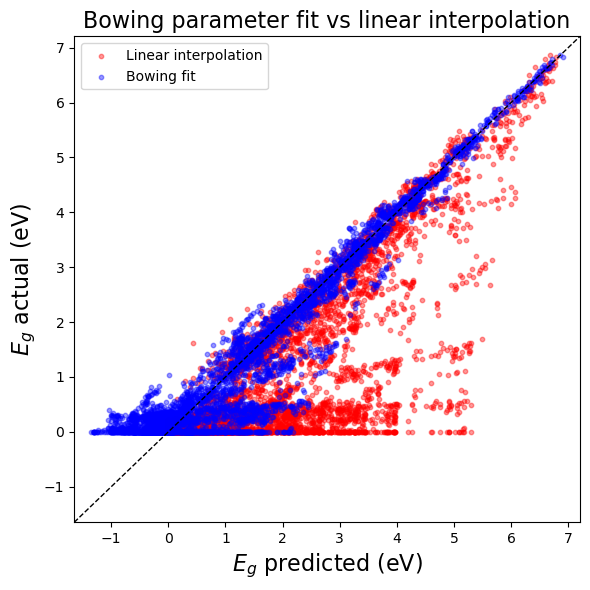

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(parity_df['Eg_linear'], parity_df['Eg_actual'], 
           color='red', alpha=0.4, s=10, label='Linear interpolation')
ax.scatter(parity_df['Eg_bowing'], parity_df['Eg_actual'],
           color='blue', alpha=0.4, s=10, label='Bowing fit')
lim = [parity_df[['Eg_actual','Eg_linear','Eg_bowing']].min().min() - 0.3,
       parity_df[['Eg_actual','Eg_linear','Eg_bowing']].max().max() + 0.3]
ax.plot(lim, lim, 'k--', lw=1)
ax.set_ylim(lim); ax.set_xlim(lim)
ax.set_ylabel('$E_g$ actual (eV)'); ax.set_xlabel('$E_g$ predicted (eV)')
ax.set_title('Bowing parameter fit vs linear interpolation')
ax.legend()
plt.tight_layout(); plt.show()

In [21]:
set(bowing_df['B_pair_group'])

{'AEM-AEM', 'AEM-PTM', 'AEM-TM', 'PTM-PTM', 'PTM-TM', 'TM-TM'}

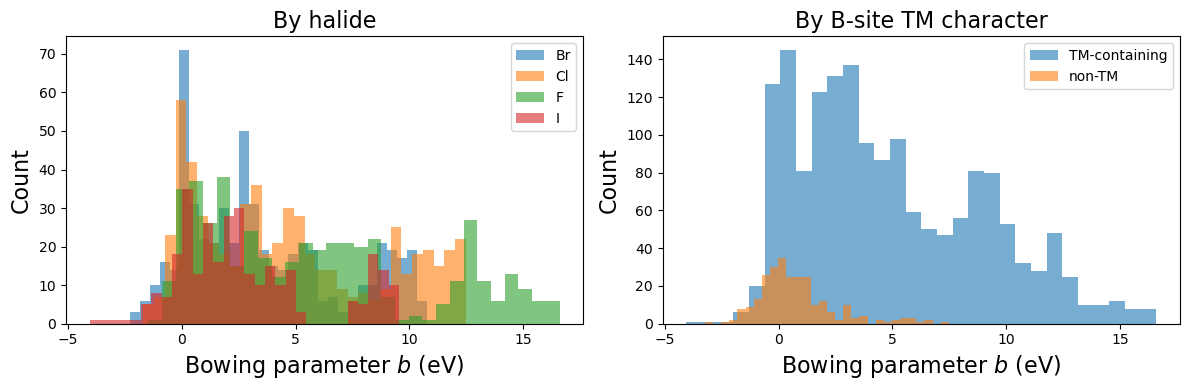

In [22]:
bowing_df['TM_group'] = bowing_df['B_pair_group'].apply(
    lambda s: 'TM-containing' if '-TM' in s else 'non-TM'
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(axes,
                           ['X', 'TM_group'],
                           ['By halide', 'By B-site TM character']):
    for label, sub in bowing_df.groupby(col):
        ax.hist(sub['b'], bins=30, alpha=0.6, label=label)
    ax.set_xlabel('Bowing parameter $b$ (eV)')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend()

plt.tight_layout(); plt.show()


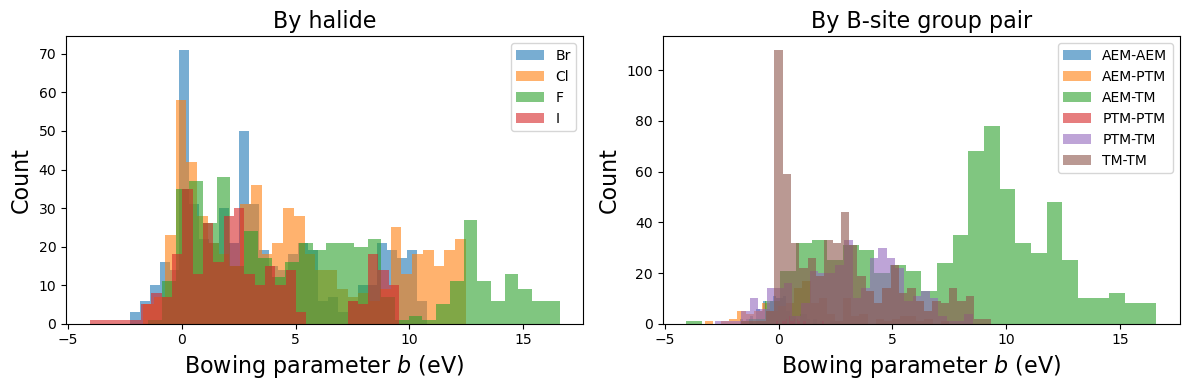

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(axes,
                           ['X', 'B_pair_group'],
                           ['By halide', 'By B-site group pair']):
    for label, sub in bowing_df.groupby(col):
        ax.hist(sub['b'], bins=30, alpha=0.6, label=label)
    ax.set_xlabel('Bowing parameter $b$ (eV)')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend()

plt.tight_layout(); plt.show()

In [24]:
# EDA, stability vs heuristics
# t = (rA + rX) / (sqrt(2)*(rB + rX))
# tau = rX/rB - nA*(nA-(rA/rB)/ln(rA/rB))
# extract dHd from alloy_df and pure_phases_df
# calculate t and tau
# parity between dHd and t, and between dHd and tau, see if there are any trends or correlations



In [25]:
from pymatgen.core import Species

def safe_radius(element, ox, cn, radius_type, spin = None):
    try:
        r = Species(element, ox).get_shannon_radius(cn = cn, spin = spin, radius_type = radius_type)
        return r if r is not None else np.nan
    except Exception:
        return np.nan

# Precompute radius lookups
all_A = set(pure_phases_df['A1'].dropna()) | set(pure_phases_df['A2'].dropna()) | \
        set(alloy_df['A1'].dropna())        | set(alloy_df['A2'].dropna())
all_B = set(pure_phases_df['B']) | set(alloy_df['B1']) | set(alloy_df['B2'])
all_X = {'F', 'Cl', 'Br', 'I'}

r_A = {el: safe_radius(el, +1, 'XII', 'ionic', 'High Spin') for el in all_A}
r_B = {el: safe_radius(el, +2, 'VI', 'ionic', 'High Spin') for el in all_B}
r_X = {el: safe_radius(el, -1, 'VI', 'ionic', 'High Spin') for el in all_X}

r_A_supplementary = {'Ag': 1.52} # missing el from ML https://cmd-ml.github.io/
r_B_supplementary = {'Sn': 1.02} # missing el from ML https://cmd-ml.github.io/
r_A.update(r_A_supplementary)
r_B.update(r_B_supplementary)

def tol_factors(rA, rB, rX, nA=1):
    t   = (rA + rX) / (np.sqrt(2) * (rB + rX))
    ratio = rA / rB
    tau = rX/rB - nA*(nA - ratio/np.log(ratio)) if ratio > 0 and ratio != 1 else np.nan
    return t, tau

def get_rA(row, A1_col='A1', A2_col='A2'):
    rA1 = r_A.get(row[A1_col], np.nan)
    A2  = row.get(A2_col)
    rA2 = r_A.get(A2, np.nan) if pd.notna(A2) else np.nan
    return rA1 if np.isnan(rA2) else (rA1 + rA2) / 2

# Pure phases
records = []
for _, row in pure_phases_df.iterrows():
    rA = get_rA(row)
    rB = r_B.get(row['B'], np.nan)
    rXv = r_X.get(row['X'], np.nan)
    if any(np.isnan(v) for v in [rA, rB, rXv]) or pd.isna(row['dHd']):
        continue
    t, tau = tol_factors(rA, rB, rXv)
    records.append({'formula': row['formula'], 'dHd': row['dHd'],
                    't': t, 'tau': tau, 'type': 'pure'})

# Alloys (compositionally weighted B-site)
for _, row in alloy_df.iterrows():
    rA  = get_rA(row)
    x   = row['x'] / 100.0
    rB1 = r_B.get(row['B1'], np.nan)
    rB2 = r_B.get(row['B2'], np.nan)
    rB  = rB1**(1-x) * rB2**(x)   # weighted geometric mean
    # rB  = rB1*(1-x) + rB2*(x)   # weighted arithmetic mean
    rXv = r_X.get(row['X'], np.nan)
    if any(np.isnan(v) for v in [rA, rB, rXv]) or pd.isna(row['dHd']):
        continue
    t, tau = tol_factors(rA, rB, rXv)
    records.append({'formula': row['formula'], 'dHd': row['dHd'],
                    't': t, 'tau': tau, 'type': 'alloy'})

stability_df = pd.DataFrame(records)
print(f"{len(stability_df)} rows with complete tolerance factor + dHd data")
print(f"  pure: {(stability_df['type']=='pure').sum()}, alloy: {(stability_df['type']=='alloy').sum()}")
print(f"  Skipped due to missing radius or dHd: {len(alloy_df)+len(pure_phases_df)-len(stability_df)}")


c:\anaconda3\envs\pmg\lib\site-packages\pymatgen\core\periodic_table.py:1288: UserWarning: Specified spin state of High Spin not consistent with database spin of . Only one spin data available, and that value is returned.
  warnings.warn(


6511 rows with complete tolerance factor + dHd data
  pure: 523, alloy: 5988
  Skipped due to missing radius or dHd: 177


In [26]:
stability_df.columns

Index(['formula', 'dHd', 't', 'tau', 'type'], dtype='object')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


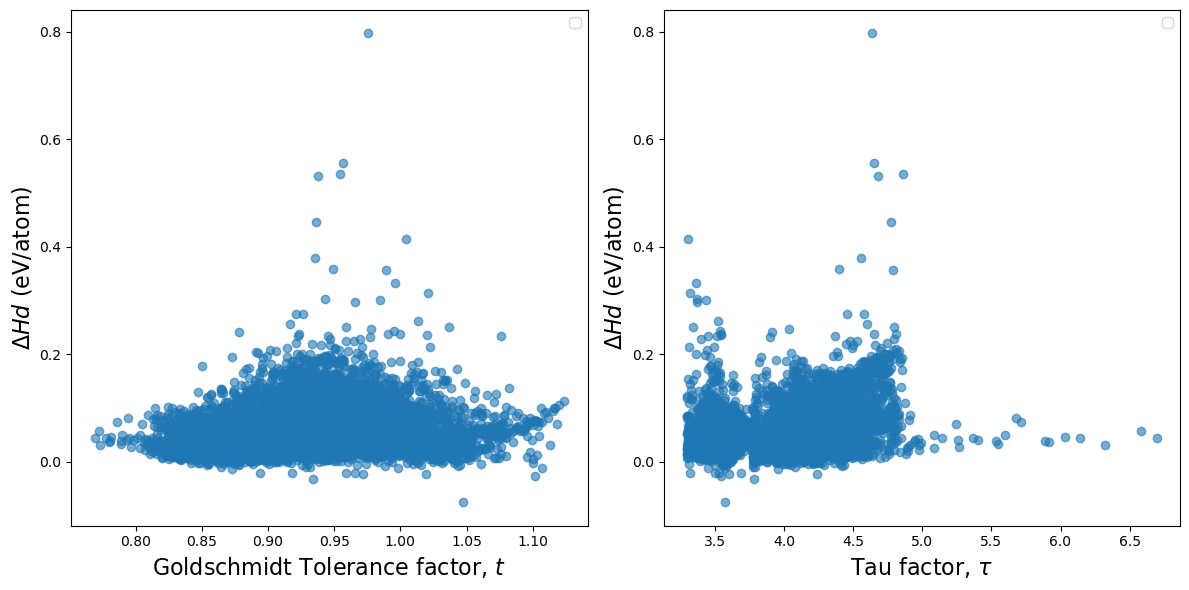

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, col, y_label in zip(axes,
                           ['t', 'tau'],
                           ['Goldschmidt Tolerance factor, $t$', 'Tau factor, $\\tau$']):
    ax.scatter(stability_df[col], stability_df['dHd'], alpha=0.6)
    ax.set_xlabel(y_label)
    ax.set_ylabel('$\Delta Hd$ (eV/atom)')
    # ax.set_title(title)
    # ax.legend()

plt.tight_layout(); plt.show()